# IF3170 Artificial Intelligence | Tugas Besar 2


Group Number: 12

Group Members:
- Surya Suharna (18223075)
- Muhammad Aymar Barkhaya (18223051)
- Ni Made Sekar Jelita Parameswari (18223101)
- Muhammad Azzam Robbani (18223025)


## Import Libraries

In [781]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif, f_classif, chi2
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import warnings
import missingno as msno
from sklearn.preprocessing import PowerTransformer
from sklearn.datasets import make_classification
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## Import Dataset

In [782]:
# Import dataset
import os

# Try to load data from data directory
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)
print("\n=== Data Overview ===")
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Number of features: {train_df.shape[1] - 1}")
print(f"\nTarget distribution:")
print(train_df['is_fraud'].value_counts())
print(f"Fraud percentage: {train_df['is_fraud'].mean()*100:.2f}%")

Train dataset shape: (100000, 31)
Test dataset shape: (100000, 30)

=== Data Overview ===
Training samples: 100,000
Test samples: 100,000
Number of features: 30

Target distribution:
is_fraud
0    85872
1    14128
Name: count, dtype: int64
Fraud percentage: 14.13%


In [783]:
# Display basic information
print("=== Training Data Info ===")
print(train_df.info())
print("\n=== Training Data Description ===")
print(train_df.describe())
print("\n=== Missing Values ===")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

## Inspecting Data

In [784]:
# Check Data Size
print(f"Jumlah baris: {train_df.shape[0]}, Jumlah kolom: {train_df.shape[1]}")

Jumlah baris: 100000, Jumlah kolom: 31


In [785]:
# Identify Data Types
print(train_df.dtypes)

ID                          int64
transaction_id             object
user_id                     int64
age                         int64
gender                     object
country                    object
device_type                object
device_os                  object
merchant_category          object
transaction_amount        float64
transaction_type           object
time_of_day                 int64
day_of_week                 int64
transaction_duration      float64
num_prev_transactions       int64
avg_transaction_amount    float64
std_transaction_amount    float64
transactions_last_24h       int64
transactions_last_1h        int64
failed_login_attempts       int64
ip_risk_score             float64
device_trust_score        float64
account_age_days            int64
has_chargeback_history      int64
shared_ip_users             int64
shared_device_users         int64
merchant_risk             float64
country_risk              float64
distance_from_home        float64
is_new_country


Features with missing values:
['transaction_amount', 'avg_transaction_amount', 'device_trust_score']

Total count of missing values in the dataset:
7257

Total Count of missing values per feature:
ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        2419
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    2419
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        2419
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users        

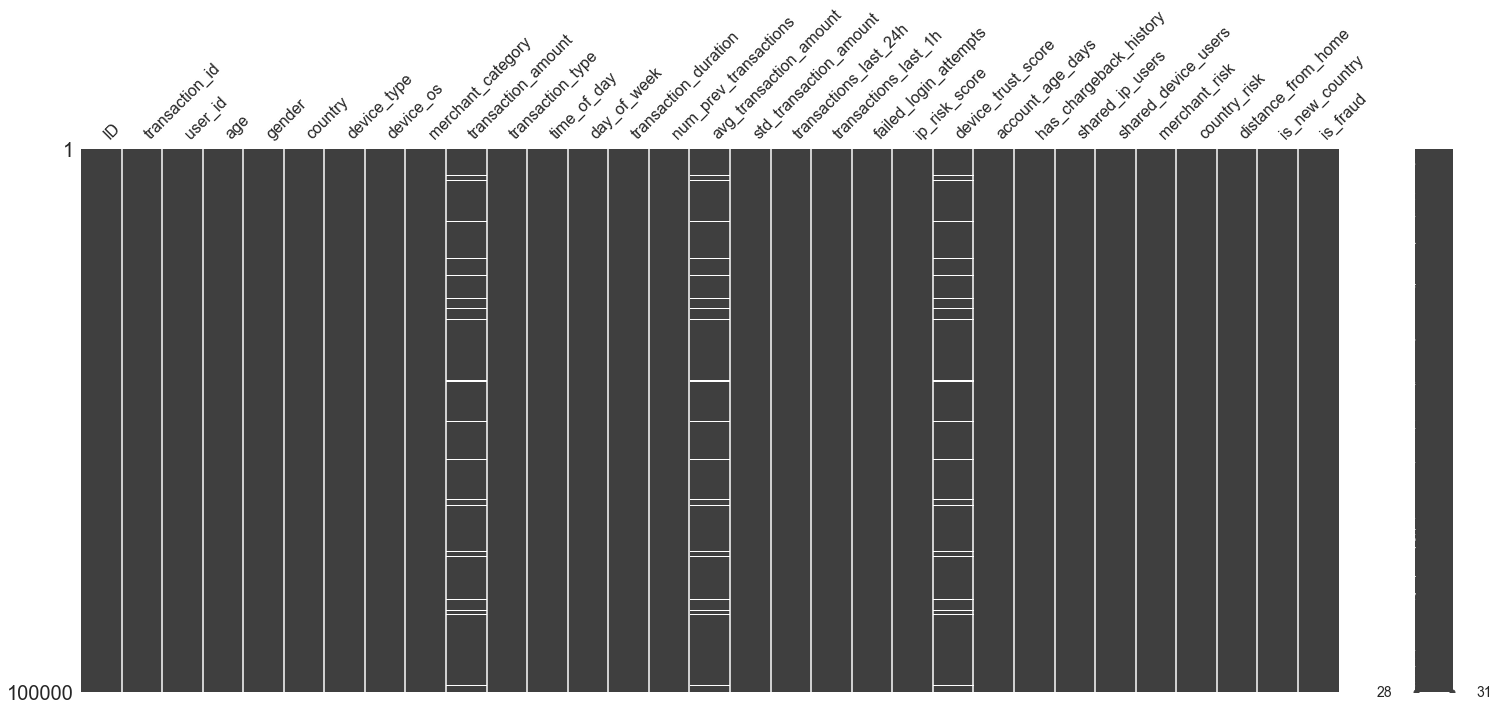

In [786]:
# Which feature has missing values?
print("\nFeatures with missing values:")
print([col for col in train_df.columns if train_df[col].isnull().any()])

print("\nTotal count of missing values in the dataset:")
print(train_df.isnull().values.sum())

print("\nTotal Count of missing values per feature:")
print(train_df.isna().sum())

# Visualize missing values
msno.matrix(train_df)
plt.show()

In [787]:
# Display basic information
print("=== Training Data Info ===")
print(train_df.info())


=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64

In [788]:
# Unique Values in Categorical Features

#Transaction Type
print("Transaction Type Description and Unique Values:")
transaction_type_desc = train_df["transaction_type"].describe()
unique_transtype = train_df['transaction_type'].unique()

print(transaction_type_desc)
print(unique_transtype)

# Device OS
print("\nDevice OS Description and Unique Values:")
deviceos_desc = train_df["device_os"].describe()
unique_deviceos = train_df['device_os'].unique()

print(deviceos_desc)
print(unique_deviceos)

# Device Type
print("\nDevice Type Description and Unique Values:")
devicetype_desc = train_df["device_type"].describe()
unique_devicetype = train_df['device_type'].unique()

print(devicetype_desc)
print(unique_devicetype)

Transaction Type Description and Unique Values:
count       100000
unique           4
top       purchase
freq         59395
Name: transaction_type, dtype: object
['purchase' 'topup' 'withdrawal' 'transfer']

Device OS Description and Unique Values:
count      100000
unique          5
top       Android
freq        49183
Name: device_os, dtype: object
['Android' 'iOS' 'Windows' 'Linux' 'MacOS']

Device Type Description and Unique Values:
count     100000
unique         3
top       mobile
freq       78292
Name: device_type, dtype: object
['mobile' 'desktop' 'tablet']


## Exploring Data Characteristics

In [789]:
print("=== Statistik Deskriptif untuk Data Numerik ===\n")
print(train_df.describe())

=== Statistik Deskriptif untuk Data Numerik ===

                  ID        user_id            age  transaction_amount  \
count  100000.000000  100000.000000  100000.000000        97581.000000   
mean    49999.500000   15040.173180      48.484150          126.855288   
std     28867.657797    8655.074007      17.892168          376.035544   
min         0.000000       1.000000      18.000000            0.010000   
25%     24999.750000    7549.000000      33.000000           26.910000   
50%     49999.500000   15093.000000      48.000000           64.460000   
75%     74999.250000   22541.000000      64.000000          131.060000   
max     99999.000000   29999.000000      79.000000        20601.133350   

         time_of_day    day_of_week  transaction_duration  \
count  100000.000000  100000.000000         100000.000000   
mean       12.770160       2.780700              3.999587   
std         5.748626       2.064754              4.012831   
min         0.000000       0.000000     

## Eksplorasi Data

In [790]:
# Summary Statistics of Numerical Features including Skewness and Kurtosis
summary = pd.DataFrame()

summary["min"] = train_df.min(numeric_only=True)
summary["max"] = train_df.max(numeric_only=True)
summary["mean"] = train_df.mean(numeric_only=True)
summary["median"] = train_df.median(numeric_only=True)
summary["mode"] = train_df.mode(numeric_only=True).iloc[0]
summary["std"] = train_df.std(numeric_only=True)
summary["skewness"] = train_df.skew(numeric_only=True)
summary["kurtosis"] = train_df.kurtosis(numeric_only=True)


summary

,min,max,mean,median,mode,std,skewness,kurtosis
ID,0.00,99999.000000,49999.500000,49999.500,0.000,28867.657797,0.000000,-1.200000
user_id,1.00,29999.000000,15040.173180,15093.000,18896.000,8655.074007,-0.007491,-1.197771
age,18.00,79.000000,48.484150,48.000,40.000,17.892168,0.002919,-1.195800
transaction_amount,0.01,20601.133350,126.855288,64.460,0.190,376.035544,14.793343,330.302199
time_of_day,0.00,23.000000,12.770160,12.000,18.000,5.748626,-0.184745,-1.021863
day_of_week,0.00,6.000000,2.780700,3.000,0.000,2.064754,0.066893,-1.375726
transaction_duration,0.00,52.070000,3.999587,2.760,0.140,4.012831,2.021264,6.248908
num_prev_transactions,8.00,59.000000,29.992080,30.000,29.000,5.486210,0.179529,0.030904
avg_transaction_amount,-52.89,195.790000,69.969722,69.990,84.350,29.961530,-0.000764,-0.034694
std_transaction_amount,5.00,80.000000,42.541209,42.480,47.350,21.652791,-0.000783,-1.198752


## Visualizing Relationship of Data

### Categorical Data

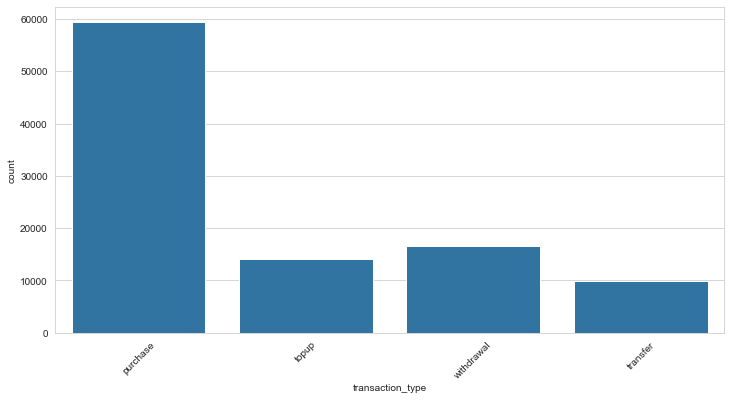

In [791]:
# Visualisasi Distribusi Kategori transaction_type
sns.countplot(data=train_df, x="transaction_type")
plt.xticks(rotation=45)
plt.show()

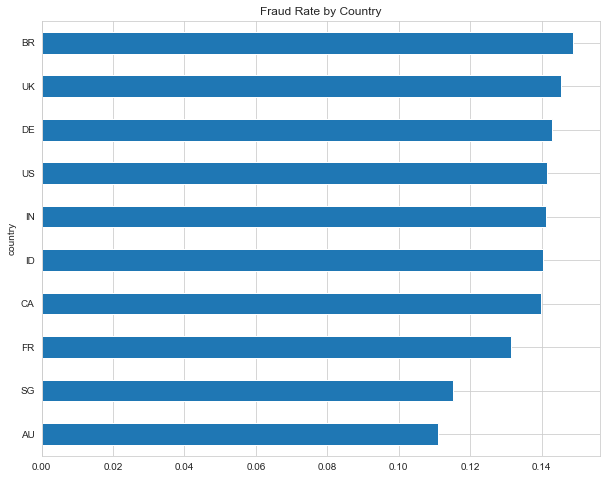

In [792]:
train_eda = train_df.copy()
(train_eda.groupby("country")["is_fraud"]
    .mean()
    .sort_values(ascending=True)
    .plot(kind="barh", figsize=(10,8)))
plt.title("Fraud Rate by Country")
plt.show()

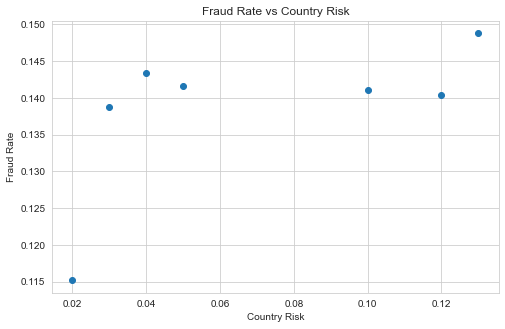

In [793]:
risk_fraud = (
    train_df.groupby('country_risk')['is_fraud']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.scatter(risk_fraud['country_risk'], risk_fraud['is_fraud'])
plt.xlabel("Country Risk")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate vs Country Risk")
plt.show()


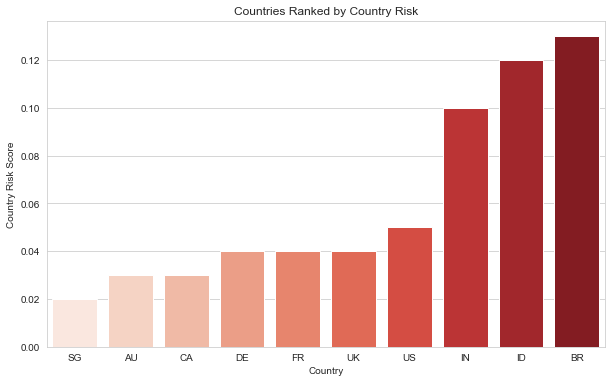

In [794]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=train_df.groupby(["country", "country_risk"]).size().reset_index(name="count")
            .sort_values("country_risk", ascending=True),
    x="country",
    y="country_risk",
    palette="Reds"
)

plt.title("Countries Ranked by Country Risk")
plt.ylabel("Country Risk Score")
plt.xlabel("Country")
plt.show()


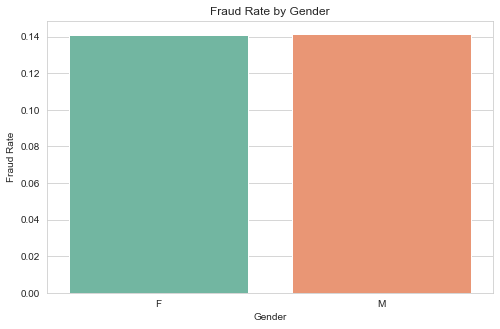

In [795]:
fraud_gender = (
    train_eda.groupby("gender")["is_fraud"]
      .mean()
      .reset_index()
      .rename(columns={"is_fraud": "fraud_rate"})
)

plt.figure(figsize=(8,5))
sns.barplot(data=fraud_gender, x="gender", y="fraud_rate", palette="Set2")

plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate")
plt.show()


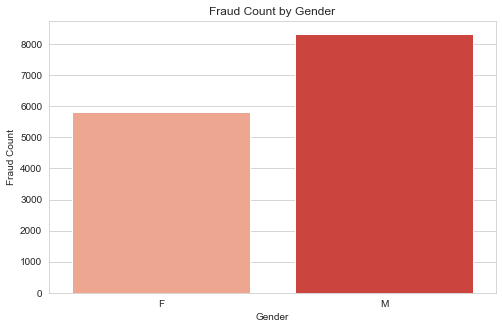

In [796]:
fraud_count_gender = (
    train_eda[train_eda["is_fraud"] == 1]
    .groupby("gender")
    .size()
    .reset_index(name="fraud_count")
)

plt.figure(figsize=(8,5))
sns.barplot(data=fraud_count_gender, x="gender", y="fraud_count", palette="Reds")

plt.title("Fraud Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Count")
plt.show()


In [797]:
bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]

train_eda["age_group"] = pd.cut(train_eda["age"], bins=bins, labels=labels, right=False)


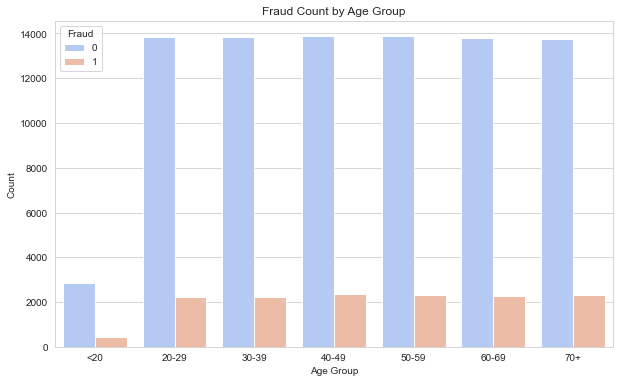

In [798]:
plt.figure(figsize=(10,6))
sns.countplot(data=train_eda, x="age_group", hue="is_fraud", palette="coolwarm")

plt.title("Fraud Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Fraud")
plt.show()


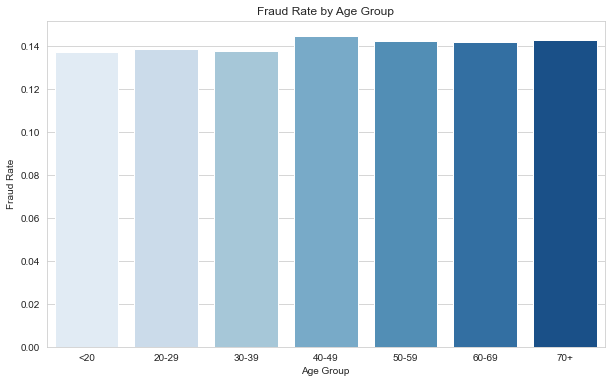

In [799]:
fraud_age = (
    train_eda.groupby("age_group")["is_fraud"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=fraud_age, x="age_group", y="is_fraud", palette="Blues")

plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")
plt.show()


In [800]:
cat_cols = [col for col in train_df.columns 
            if train_df[col].dtype == 'object' or train_df[col].dtype.name == 'category']

#Unique values in categorical features
for col in cat_cols:
    print(col, train_df[col].nunique())

transaction_id 100000
gender 2
country 10
device_type 3
device_os 5
merchant_category 9
transaction_type 4


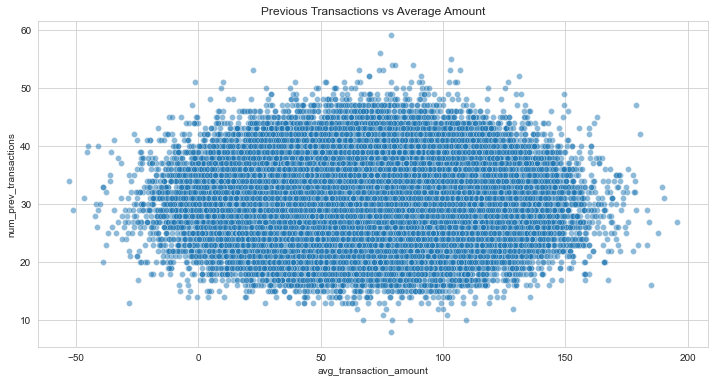

In [801]:
sns.scatterplot(data=train_eda, x="avg_transaction_amount", 
                y="num_prev_transactions", alpha=0.5)
plt.title("Previous Transactions vs Average Amount")
plt.show()

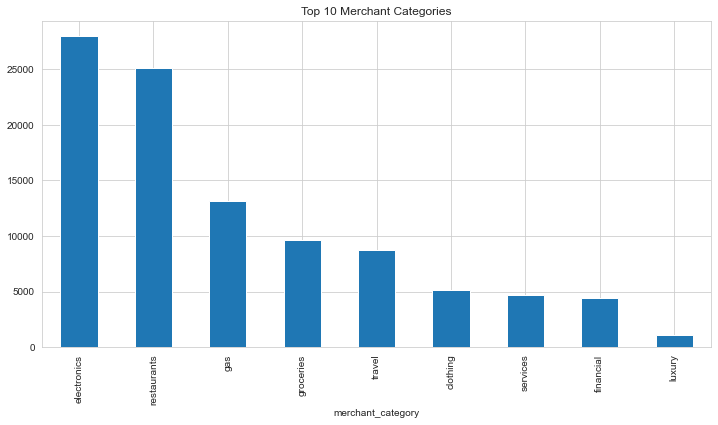

In [802]:
train_eda["merchant_category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Merchant Categories")
plt.show()


# 1. Split Training Set, Validation Set, Testing Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [803]:
raw_data = train_df.copy()
raw_train = train_df.copy()
X_test = test_df.copy()

In [804]:
# Separate features and target () train.csv
X_full = raw_train.drop('is_fraud', axis=1) # features
y_full = raw_train['is_fraud'] #target feature: is_fraud

In [805]:
# Separate features and target () train.csv yang akan di-split
X = raw_data.drop('is_fraud', axis=1) # features
y = raw_data['is_fraud'] #target feature: is_fraud

# Splitting training data into train set and val set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# X_train 80% feature
# y_train 80% of target values
# X_val 20% feature
# y_val 20% of target values

print(f"Training set size: {len(X_train):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"\nTraining set fraud rate: {y_train.mean()*100:.2f}%")
print(f"Validation set fraud rate: {y_val.mean()*100:.2f}%")

Training set size: 80,000
Validation set size: 20,000

Training set fraud rate: 14.13%
Validation set fraud rate: 14.13%


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [806]:
# Check all missing values

X_train.isnull().sum()

ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        1920
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    1920
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        1920
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users          0
merchant_risk                0
country_risk                 0
distance_from_home           0
is_new_country               0
dtype: int64

In [807]:
X_val.isnull().sum()

ID                          0
transaction_id              0
user_id                     0
age                         0
gender                      0
country                     0
device_type                 0
device_os                   0
merchant_category           0
transaction_amount        499
transaction_type            0
time_of_day                 0
day_of_week                 0
transaction_duration        0
num_prev_transactions       0
avg_transaction_amount    499
std_transaction_amount      0
transactions_last_24h       0
transactions_last_1h        0
failed_login_attempts       0
ip_risk_score               0
device_trust_score        499
account_age_days            0
has_chargeback_history      0
shared_ip_users             0
shared_device_users         0
merchant_risk               0
country_risk                0
distance_from_home          0
is_new_country              0
dtype: int64

In [808]:
# Create flags for missing values
def create_null_flags(X):
    X = X.copy()
    X['device_trust_score_missing'] = X['device_trust_score'].isnull().astype(int)
    X['avg_transaction_amount_missing'] = X['avg_transaction_amount'].isnull().astype(int)
    X['transaction_amount_missing'] = X['transaction_amount'].isnull().astype(int)

    return X

X_full = create_null_flags(X_full)
X_train = create_null_flags(X_train)
X_val = create_null_flags(X_val)
X_test = create_null_flags(X_test)
print("Missing value flags created successfully!")

Missing value flags created successfully!


In [809]:
# Imputing median on the missing values
def impute_median(X):
    X = X.copy()
    X['transaction_amount'].fillna(X['transaction_amount'].median(), inplace=True)
    X['avg_transaction_amount'].fillna(X['avg_transaction_amount'].median(), inplace=True)
    X['device_trust_score'].fillna(X['device_trust_score'].median(), inplace=True)
    
    return X

X_full = impute_median(X_full)
X_train = impute_median(X_train)
X_val = impute_median(X_val)
X_test = impute_median(X_test)
print("Missing value imputed with median successfully!")

Missing value imputed with median successfully!


In [810]:
# Data sudah tidak memiliki nilai null lagi, yay!
X_train.isnull().sum()

ID                                0
transaction_id                    0
user_id                           0
age                               0
gender                            0
country                           0
device_type                       0
device_os                         0
merchant_category                 0
transaction_amount                0
transaction_type                  0
time_of_day                       0
day_of_week                       0
transaction_duration              0
num_prev_transactions             0
avg_transaction_amount            0
std_transaction_amount            0
transactions_last_24h             0
transactions_last_1h              0
failed_login_attempts             0
ip_risk_score                     0
device_trust_score                0
account_age_days                  0
has_chargeback_history            0
shared_ip_users                   0
shared_device_users               0
merchant_risk                     0
country_risk                

In [811]:
X_val.isnull().sum()

ID                                0
transaction_id                    0
user_id                           0
age                               0
gender                            0
country                           0
device_type                       0
device_os                         0
merchant_category                 0
transaction_amount                0
transaction_type                  0
time_of_day                       0
day_of_week                       0
transaction_duration              0
num_prev_transactions             0
avg_transaction_amount            0
std_transaction_amount            0
transactions_last_24h             0
transactions_last_1h              0
failed_login_attempts             0
ip_risk_score                     0
device_trust_score                0
account_age_days                  0
has_chargeback_history            0
shared_ip_users                   0
shared_device_users               0
merchant_risk                     0
country_risk                

In [812]:
null_summary = pd.DataFrame({
    'Null Count': train_eda.isnull().sum(),
    'Percentage (%)': (train_eda.isnull().sum() / len(train_eda)) * 100
})

# Sort by percentage (highest first) and show only columns that actually have nulls
null_summary = null_summary.sort_values(by='Percentage (%)', ascending=False)

print(null_summary)

                        Null Count  Percentage (%)
transaction_amount            2419           2.419
avg_transaction_amount        2419           2.419
device_trust_score            2419           2.419
ID                               0           0.000
failed_login_attempts            0           0.000
ip_risk_score                    0           0.000
account_age_days                 0           0.000
has_chargeback_history           0           0.000
shared_ip_users                  0           0.000
transactions_last_24h            0           0.000
shared_device_users              0           0.000
merchant_risk                    0           0.000
country_risk                     0           0.000
distance_from_home               0           0.000
is_new_country                   0           0.000
is_fraud                         0           0.000
transactions_last_1h             0           0.000
std_transaction_amount           0           0.000
transaction_id                 

Ada 3 kolom numerik yang memiliki data hilang, masing-masing sejumlah 2419 baris dari total 100.000, atau sekitar 2.419%:

*   transaction_amount
*   avg_transaction_amount
*   device_trust_score

Persentase data yang null cukup rendah (2.419%). Meskipun begitu, jika dibandingkan dengan data lain yang memiliki null value, skewness dari data transaction_amount itu termasuk tinggi (14.793343). Untuk mengatasi null value ini, kami akan melakukan imputation median value karena persentase null value yang kecil dan juga cepat di-compute.

 Feature device_trust_score yang memiliki null value bisa saja mengindikasikan fraud karena pengguna bisa saja menggunakan incognito mode atau metode serupa lainnya untuk melakukan transaksi. Meskipun begitu, dua fitur lainnya bisa saja memiliki null value karena galat data processing.

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

Consideration on handling the outliers:
- The features that might represent user behavior, e.g. transaction_amount, device_trust_score
- The outliers could be the fraud cases

What must be removed: Invalid values and errors

In [813]:
def iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [814]:
def outlier_count(X):
    ta_lower_bound, ta_upper_bound = iqr(X, 'transaction_amount')
    avgta_lower_bound, avgta_upper_bound = iqr(X, 'avg_transaction_amount')
    tl24h_lower_bound, tl24h_upper_bound = iqr(X, 'transactions_last_24h')
    tl1h_lower_bound, tl1h_upper_bound = iqr(X, 'transactions_last_1h')
    td_lower_bound, td_upper_bound = iqr(X, 'transaction_duration')
    fla_lower_bound, fla_upper_bound = iqr(X, 'failed_login_attempts')
    agd_lower_bound, agd_upper_bound = iqr(X, 'account_age_days')
    dfh_lower_bound, dfh_upper_bound = iqr(X, 'distance_from_home')
    npt_lower_bound, npt_upper_bound = iqr(X, 'num_prev_transactions')

    ta_outliers = X[(X['transaction_amount'] < ta_lower_bound) | (X['transaction_amount'] > ta_upper_bound)]
    avgta_outliers = X[(X['avg_transaction_amount'] < avgta_lower_bound) | (X['avg_transaction_amount'] > avgta_upper_bound)]
    tl24h_outliers = X[(X['transactions_last_24h'] < tl24h_lower_bound) | (X['transactions_last_24h'] > tl24h_upper_bound)]
    tl1h_outliers = X[(X['transactions_last_1h'] < tl1h_lower_bound) | (X['transactions_last_1h'] > tl1h_upper_bound)]
    td_outliers = X[(X['transaction_duration'] < td_lower_bound) | (X['transaction_duration'] > td_upper_bound)]
    fla_outliers = X[(X['failed_login_attempts'] < fla_lower_bound) | (X['failed_login_attempts'] > fla_upper_bound)]
    agd_outliers = X[(X['account_age_days'] < agd_lower_bound) | (X['account_age_days'] > agd_upper_bound)]
    dfh_outliers = X[(X['distance_from_home'] < dfh_lower_bound) | (X['distance_from_home'] > dfh_upper_bound)]
    npt_outliers = X[(X['num_prev_transactions'] < npt_lower_bound) | (X['num_prev_transactions'] > npt_upper_bound)]

    print("Number of outliers in transaction_amount:", len(ta_outliers))
    print("Percentage of outliers in transaction_amount:", len(ta_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in avg_transaction_amount:", len(avgta_outliers))
    print("Percentage of outliers in avg_transaction_amount:", len(avgta_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in transactions_last_24h:", len(tl24h_outliers))
    print("Percentage of outliers in transactions_last_24h:", len(tl24h_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in transactions_last_1h:", len(tl1h_outliers))
    print("Percentage of outliers in transactions_last_1h:", len(tl1h_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in transaction_duration:", len(td_outliers))
    print("Percentage of outliers in transaction_duration:", len(td_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in failed_login_attempts:", len(fla_outliers))
    print("Percentage of outliers in failed_login_attempts:", len(fla_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in account_age_days:", len(agd_outliers))
    print("Percentage of outliers in account_age_days:", len(agd_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in distance_from_home:", len(dfh_outliers))
    print("Percentage of outliers in distance_from_home:", len(dfh_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in num_prev_transactions:", len(npt_outliers))
    print("Percentage of outliers in num_prev_transactions:", len(npt_outliers)/len(X) * 100, "%")

outlier_count(X_full)
# outlier_count(X_train)
# outlier_count(X_val)
# outlier_count(X_test)

Number of outliers in transaction_amount: 6247
Percentage of outliers in transaction_amount: 6.247 %

Number of outliers in avg_transaction_amount: 815
Percentage of outliers in avg_transaction_amount: 0.815 %

Number of outliers in transactions_last_24h: 8878
Percentage of outliers in transactions_last_24h: 8.878 %

Number of outliers in transactions_last_1h: 11697
Percentage of outliers in transactions_last_1h: 11.697000000000001 %

Number of outliers in transaction_duration: 4903
Percentage of outliers in transaction_duration: 4.903 %

Number of outliers in failed_login_attempts: 363
Percentage of outliers in failed_login_attempts: 0.363 %

Number of outliers in account_age_days: 0
Percentage of outliers in account_age_days: 0.0 %

Number of outliers in distance_from_home: 5550
Percentage of outliers in distance_from_home: 5.55 %

Number of outliers in num_prev_transactions: 264
Percentage of outliers in num_prev_transactions: 0.264 %


Dalam kasus fraud detection, outliers memiliki kemungkinan besar sebagai data yang mengindikasi fraud. Oleh karena itu, outlier tidak dihapus ataupun di-impute

### III. Data Validation

In [815]:
# Mengecek validitas value berdasarkan constraint yang dijelaskan di Tabel Penjelasan Data

def check_value_validity(X):
    print("transaction_amount:" , (X['transaction_amount'] < 0).sum())
    print("device_trust_score:" , (X['device_trust_score'] > 1).sum())
    print("time_of_day:" , ((X['time_of_day'] < 0) | (X['time_of_day'] > 23)).sum())
    print("day_of_week:" , ((X['day_of_week'] < 0) | (X['day_of_week'] > 6)).sum())
    print("transaction_duration:" , (X['transaction_duration'] < 1).sum(), ", " , (X['transaction_duration'] < 1).sum()/len(X) * 100, "%")
    print("avg_transaction_amount:" , (X['avg_transaction_amount'] < 0).sum(), ", " , (X['avg_transaction_amount'] < 0).sum()/len(X) * 100, "%")
    print("std_transaction_amount:" , (X['std_transaction_amount'] < 0).sum())
    print("transactions_last_24h:" , (X['transactions_last_24h'] < 0).sum())
    print("transactions_last_1h:" , (X['transactions_last_1h'] < 0).sum())
    print("ip_risk_score:" , ((X['ip_risk_score'] < 0) | (X['ip_risk_score'] > 1)).sum())
    print("device_trust_score:" , ((X['device_trust_score'] < 0) | (X['device_trust_score'] > 1)).sum())
    print("account_age_days:" , (X['account_age_days'] < 1).sum())
    print("merchant_risk:" , (X['merchant_risk'] < 0).sum())
    print("country_risk:" , (X['country_risk'] < 0).sum())
    print("distance_from_home:" , (X['distance_from_home'] < 0).sum())

check_value_validity(X_full)
# check_value_validity(X_train)
# check_value_validity(X_val)
# check_value_validity(X_test)

transaction_amount: 0
device_trust_score: 0
time_of_day: 0
day_of_week: 0
transaction_duration: 22059 ,  22.059 %
avg_transaction_amount: 924 ,  0.924 %
std_transaction_amount: 0
transactions_last_24h: 0
transactions_last_1h: 0
ip_risk_score: 0
device_trust_score: 0
account_age_days: 0
merchant_risk: 0
country_risk: 0
distance_from_home: 0


Terlihat bahwa terdapat transaction_duration dengan value < 1 sebanyak 22059 (22.059%) data dan avg_transaction_amount dengan value negatif sebanyak 924 (0.924%) data. 

Data yang invalid pada feature transaction_duration cukup besar (22.059%) sehingga dipertimbangkan untuk melakukan data imputation dengan median value dan memberikan kolom flag (Missing indicator)

Untuk feature avg_transaction_amount, tidak terlalu banyak yang invalid (0.924%). Oleh karena itu, hanya dilakukan data imputation dengan median value

In [816]:
def handle_invalid_value(X):
    # Missing indicator dengan transaction_duration_zero
    X['transaction_duration_zero'] = (X['transaction_duration'] < 1).astype(int)

    # Replace dengan NaN values
    X.loc[X['transaction_duration'] < 1, 'transaction_duration'] = np.nan

    # Impute median values
    X['transaction_duration'] = X['transaction_duration'].fillna(X['transaction_duration'].median())

    # # Replace dengan NaN values
    X.loc[X['avg_transaction_amount'] < 0,'avg_transaction_amount'] = np.nan

    # # Impute median values
    X['avg_transaction_amount'] = X['avg_transaction_amount'].fillna(X['avg_transaction_amount'].median())

handle_invalid_value(X_full)
handle_invalid_value(X_train)
handle_invalid_value(X_val)
handle_invalid_value(X_test)

print("Invalid values handled successfully!")


Invalid values handled successfully!


### IV. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [817]:
full_duplicates_count = X_full.duplicated().sum()
train_duplicates_count = X_train.duplicated().sum()
val_duplicates_count = X_val.duplicated().sum()
test_duplicates_count = X_test.duplicated().sum()

print("Number of duplicate rows in full train set:", full_duplicates_count)
print("Number of duplicate rows in training set:", train_duplicates_count)
print("Number of duplicate rows in validation set:", val_duplicates_count)
print("Number of duplicate rows in test set:", test_duplicates_count)

Number of duplicate rows in full train set: 0
Number of duplicate rows in training set: 0
Number of duplicate rows in validation set: 0
Number of duplicate rows in test set: 0


Kesimpulan: tidak ada data duplikat

### V. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

**Reason for IQR Method & Capping:**
- **IQR Method**: Statistical method that defines outliers as values beyond Q1-1.5×IQR or Q3+1.5×IQR
- **Capping**: Preserves all data points (no deletion) while limiting extreme values
- **Advantages**: 
  - Maintains dataset size (important for limited fraud samples)
  - Reduces influence of extreme values on model
  - More robust than z-score method for skewed data

In [818]:
X_full.dtypes

ID                                  int64
transaction_id                     object
user_id                             int64
age                                 int64
gender                             object
country                            object
device_type                        object
device_os                          object
merchant_category                  object
transaction_amount                float64
transaction_type                   object
time_of_day                         int64
day_of_week                         int64
transaction_duration              float64
num_prev_transactions               int64
avg_transaction_amount            float64
std_transaction_amount            float64
transactions_last_24h               int64
transactions_last_1h                int64
failed_login_attempts               int64
ip_risk_score                     float64
device_trust_score                float64
account_age_days                    int64
has_chargeback_history            

### ---Create New Features

In [819]:
def create_new_features(X):
    X = X.copy()
    
    # Rasio transaction_amount to avg_transaction_amount
    X["amount_over_avg"] = X["transaction_amount"] / (X["avg_transaction_amount"] + 1)
    
    # Perbandingan transaction last 1h to avg hourly rate per day
    hourly_avg = X['transactions_last_24h'] / 24
    X['hourly_velocity_spike'] = X['transactions_last_1h'] / (hourly_avg + 0.1)
    
    # Jumlah transaksi per hari sejak akun dibuat
    X["amount_per_day"] = X["transaction_amount"] / (X["account_age_days"] + 1)

    # Banyak transaksi per hari sejak akun dibuat
    X["transactions_per_day"] = X["num_prev_transactions"] / (X["account_age_days"] + 1)
    
    # Transaksi besar yang baru saja terjadi
    X['high_value_burst'] = X['transaction_amount'] * X['transactions_last_1h']
    
    # Total risiko keseluruhan
    X['total_risk_index'] = (X['ip_risk_score'] * X['device_trust_score'] * X['merchant_risk'] * X['country_risk'])
    
    # Hacker behavior user: kombinasi failed login attempts dan transaksi dalam 1 jam terakhir
    X['hacker_behavior'] = X['failed_login_attempts'] * X['transactions_last_1h']
    
    # Transaksi dari luar negeri yang mencurigakan
    X['hacker_behavior'] = X['failed_login_attempts'] * X['transactions_last_1h']
    
    return X

In [820]:
X_full_new = create_new_features(X_full)
X_train_new = create_new_features(X_train)
X_val_new = create_new_features(X_val)
X_test_new = create_new_features(X_test)

### ---Feature Selection

In [821]:
# Tidak jadi menghapus data berikut
            
    # "age",                
    # "gender",             
    # "device_os",
    # "device_type",          
    # "merchant_category",
    # "country" 

In [822]:
# FEATURE SELECTION - DROP IRRELEVANT FEATURES

dropped_features = [
    "ID",                 
    "transaction_id",     
    "user_id" 
]

def feature_selection(X):
    df_selection = X.drop(columns=dropped_features)

    print("Original shape:", X.shape)
    print("After manual feature selection:", df_selection.shape)

    return df_selection

X_full_selected = feature_selection(X_full_new)
X_train_selected = feature_selection(X_train_new)
X_val_selected = feature_selection(X_val_new)
X_test_selected = feature_selection(X_test_new)

print("Removed features:", dropped_features)

Original shape: (100000, 41)
After manual feature selection: (100000, 38)
Original shape: (80000, 41)
After manual feature selection: (80000, 38)
Original shape: (20000, 41)
After manual feature selection: (20000, 38)
Original shape: (100000, 41)
After manual feature selection: (100000, 38)
Removed features: ['ID', 'transaction_id', 'user_id']


### ---One Hot Encoding

In [823]:
# One Hot Encoding for categorical features

def one_hot_encoding(X):
    X_ohe =X.copy()
    X_ohe = pd.get_dummies(X_ohe, drop_first=True, dtype=int)

    print("Encoding Complete.")
    print(f"Original Shape: {X.shape}")
    print(f"Encoded Shape:  {X_ohe.shape}")

    print("\nRemaining Object Columns:", X_ohe.select_dtypes(include=['object']).columns.tolist())
    
    return X_ohe

In [824]:
X_full_ohe = one_hot_encoding(X_full_selected)
X_train_ohe = one_hot_encoding(X_train_selected)
X_val_ohe = one_hot_encoding(X_val_selected)
X_test_ohe = one_hot_encoding(X_test_selected)

Encoding Complete.
Original Shape: (100000, 38)
Encoded Shape:  (100000, 59)

Remaining Object Columns: []
Encoding Complete.
Original Shape: (80000, 38)
Encoded Shape:  (80000, 59)

Remaining Object Columns: []
Encoding Complete.
Original Shape: (20000, 38)
Encoded Shape:  (20000, 59)

Remaining Object Columns: []
Encoding Complete.
Original Shape: (100000, 38)
Encoded Shape:  (100000, 59)

Remaining Object Columns: []


### ---RFE

Menggunakan Wrapper Method: Recursive Feature Elimination (RFE) pada data yang sudah di One Hot Encode (OHE) dan sudah di-drop feature-feature ID-ish nya.

In [ ]:
model_selector = DecisionTreeClassifier(max_depth=5, random_state=42)

# step = banyak fitur yang akan di-drop setiap iterasi
rfe = RFE(estimator=model_selector, n_features_to_select=25, step=5)
    
rfe.fit(X_train_ohe, y_train)
selected_features = X_train_ohe.columns[rfe.support_]

print("RFE Done!")
print(f"Selected {len(selected_features)} features:")
print(selected_features.tolist())

RFE Done!
Selected 25 features:
['transaction_amount', 'time_of_day', 'day_of_week', 'transaction_duration', 'num_prev_transactions', 'avg_transaction_amount', 'std_transaction_amount', 'transactions_last_24h', 'transactions_last_1h', 'failed_login_attempts', 'ip_risk_score', 'device_trust_score', 'has_chargeback_history', 'shared_ip_users', 'merchant_risk', 'country_risk', 'distance_from_home', 'is_new_country', 'device_trust_score_missing', 'amount_per_day', 'total_risk_index', 'country_US', 'device_type_mobile', 'device_os_Linux', 'merchant_category_services']


In [826]:
# ONLY FOR DTL
X_full_rfe = X_full_ohe[selected_features]
X_train_rfe = X_train_ohe[selected_features]
X_val_rfe   = X_val_ohe[selected_features]
X_test_rfe  = X_test_ohe[selected_features]

print(f"Train shape: {X_train_rfe.shape}")
print(f"Val shape:   {X_val_rfe.shape}")
print(f"Test shape:  {X_test_rfe.shape}")

Train shape: (80000, 25)
Val shape:   (20000, 25)
Test shape:  (100000, 25)


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### ---Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

### II. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

Function auto_scaling_group secara otomatis memilah feature yang berupa binary dan/atau memiliki low cardinality (categorical feature), memiliki skewness yang tinggi untuk memudahkan penentuan feature yang akan di-scale menggunakan StandardScaler ataupun RobustScaler

In [ ]:
def auto_scaling_groups(df, skew_threshold=2.0, binary_threshold=2):
    """
    Automatically selects StandardScaler or RobustScaler 
    based on skewness, and excludes binary/low-cardinality categorical vars.
    """

    # Separate binary or low-cardinality categorical values
    binary_features = [
        col for col in df.columns
        if df[col].nunique() <= binary_threshold
    ]

    skewness = df.drop(columns=binary_features).skew()

    robust_features = skewness[skewness.abs() > skew_threshold].index.tolist()
    standard_features = skewness[skewness.abs() <= skew_threshold].index.tolist()

    return {
        "binary": binary_features,
        "robust": robust_features,
        "standard": standard_features
    }

In [828]:
# FOR DTL
scaling_group_dtl = auto_scaling_groups(X_train_rfe)
robust_features_dtl = scaling_group_dtl['robust']
standard_features_dtl = scaling_group_dtl['standard']
binary_features_dtl = scaling_group_dtl['binary']

In [829]:
# FOR LOGREG AND KNN
scaling_group_logreg_knn = auto_scaling_groups(X_train_ohe)
robust_features_logreg_knn = scaling_group_logreg_knn['robust']
standard_features_logreg_knn = scaling_group_logreg_knn['standard']
binary_features_logreg_knn = scaling_group_logreg_knn['binary']

In [ ]:
# FOR DTL
print("ROBUST:", robust_features_dtl)
print("STANDARD:", standard_features_dtl)
print("BINARY:", binary_features_dtl)

ROBUST: ['transaction_amount', 'transaction_duration', 'transactions_last_24h', 'transactions_last_1h', 'distance_from_home', 'amount_per_day', 'total_risk_index']
STANDARD: ['time_of_day', 'day_of_week', 'num_prev_transactions', 'avg_transaction_amount', 'std_transaction_amount', 'failed_login_attempts', 'ip_risk_score', 'device_trust_score', 'shared_ip_users', 'merchant_risk', 'country_risk']
BINARY: ['has_chargeback_history', 'is_new_country', 'device_trust_score_missing', 'country_US', 'device_type_mobile', 'device_os_Linux', 'merchant_category_services']


In [ ]:
# FOR LOGREG AND KNN
print("ROBUST:", robust_features_logreg_knn)
print("STANDARD:", standard_features_logreg_knn)
print("BINARY:", binary_features_logreg_knn)

ROBUST: ['transaction_amount', 'transaction_duration', 'transactions_last_24h', 'transactions_last_1h', 'distance_from_home', 'amount_over_avg', 'hourly_velocity_spike', 'amount_per_day', 'transactions_per_day', 'high_value_burst', 'total_risk_index', 'hacker_behavior']
STANDARD: ['age', 'time_of_day', 'day_of_week', 'num_prev_transactions', 'avg_transaction_amount', 'std_transaction_amount', 'failed_login_attempts', 'ip_risk_score', 'device_trust_score', 'account_age_days', 'shared_ip_users', 'shared_device_users', 'merchant_risk', 'country_risk']
BINARY: ['has_chargeback_history', 'is_new_country', 'device_trust_score_missing', 'avg_transaction_amount_missing', 'transaction_amount_missing', 'transaction_duration_zero', 'gender_M', 'country_BR', 'country_CA', 'country_DE', 'country_FR', 'country_ID', 'country_IN', 'country_SG', 'country_UK', 'country_US', 'device_type_mobile', 'device_type_tablet', 'device_os_Linux', 'device_os_MacOS', 'device_os_Windows', 'device_os_iOS', 'merchant_c

In [ ]:
# Feature Scaling
print("=== FEATURE SCALING ===\n")

print(f"Numeric features to Robust Scale: {len(robust_features_logreg_knn)}")
print(f"Numeric features to Standard Scale: {len(standard_features_logreg_knn)}")
print(f"Numeric features excluded (binary/low-cardinality): {len(binary_features_logreg_knn)}\n")

print(f"Numeric features to Robust Scale: {len(robust_features_dtl)}")
print(f"Numeric features to Standard Scale: {len(standard_features_dtl)}")
print(f"Numeric features excluded (binary/low-cardinality): {len(binary_features_dtl)}\n")

standard = StandardScaler()
robust = RobustScaler()

=== DYNAMIC FEATURE SCALING ===

Numeric features to Robust Scale: 12
Numeric features to Standard Scale: 14
Numeric features excluded (binary/low-cardinality): 33

Numeric features to Robust Scale: 7
Numeric features to Standard Scale: 11
Numeric features excluded (binary/low-cardinality): 7



In [ ]:
# FOR DTL

X_full_numeric_robustscaled_dtl = robust.fit_transform(X_full_rfe[robust_features_dtl])
X_train_numeric_robustscaled_dtl = robust.fit_transform(X_train_rfe[robust_features_dtl])
X_val_numeric_robustscaled_dtl = robust.transform(X_val_rfe[robust_features_dtl])
X_test_numeric_robustscaled_dtl = robust.transform(X_test_rfe[robust_features_dtl])
X_full_numeric_standardscaled_dtl = standard.fit_transform(X_full_rfe[standard_features_dtl])
X_train_numeric_standardscaled_dtl = standard.fit_transform(X_train_rfe[standard_features_dtl])
X_val_numeric_standardscaled_dtl = standard.transform(X_val_rfe[standard_features_dtl])
X_test_numeric_standardscaled_dtl = standard.transform(X_test_rfe[standard_features_dtl])

# Convert back to DataFrame
X_full_numeric_scaled = pd.DataFrame(np.hstack([X_full_numeric_robustscaled_dtl, X_full_numeric_standardscaled_dtl]), columns=robust_features_dtl + standard_features_dtl, index=X_full_rfe.index)
X_train_numeric_scaled = pd.DataFrame(np.hstack([X_train_numeric_robustscaled_dtl, X_train_numeric_standardscaled_dtl]), columns=robust_features_dtl + standard_features_dtl, index=X_train_rfe.index)
X_val_numeric_scaled = pd.DataFrame(np.hstack([X_val_numeric_robustscaled_dtl, X_val_numeric_standardscaled_dtl]), columns=robust_features_dtl + standard_features_dtl, index=X_val_rfe.index)
X_test_numeric_scaled = pd.DataFrame(np.hstack([X_test_numeric_robustscaled_dtl, X_test_numeric_standardscaled_dtl]), columns=robust_features_dtl + standard_features_dtl, index=X_test_rfe.index)

# ===== KEEP BINARY FEATURES AS-IS =====
X_full_binary_dtl = X_full_rfe[binary_features_dtl]
X_train_binary_dtl = X_train_rfe[binary_features_dtl]
X_val_binary_dtl = X_val_rfe[binary_features_dtl]
X_test_binary_dtl = X_test_rfe[binary_features_dtl]
# ===== GABUNGKAN KEMBALI =====
X_full_scaled_dtl = pd.concat([X_full_numeric_scaled, X_full_binary_dtl], axis=1)
X_train_scaled_dtl = pd.concat([X_train_numeric_scaled, X_train_binary_dtl], axis=1)
X_val_scaled_dtl = pd.concat([X_val_numeric_scaled, X_val_binary_dtl], axis=1)
X_test_scaled_dtl = pd.concat([X_test_numeric_scaled, X_test_binary_dtl], axis=1)

print(f"✓ Scaling completed using Robust and Standard Scaler")
print(f"\nScaled training data shape: {X_train_scaled_dtl.shape}")
print(f"\nSample scaled values (first 5 rows, first 3 columns):")
print(X_train_scaled_dtl.iloc[:5])

✓ Scaling completed using Robust and Standard Scaler

Scaled training data shape: (80000, 25)

Sample scaled values (first 5 rows, first 3 columns):
       transaction_amount  transaction_duration  transactions_last_24h  \
72583            0.085706              1.326667                    3.0   
36250            1.341835              0.813333                    1.0   
96828           -0.394622              1.253333                    0.0   
99563            1.134440              4.840000                   -1.0   
43482            1.110913              0.310000                   -1.0   

       transactions_last_1h  distance_from_home  amount_per_day  \
72583                   0.0           -0.448625        0.477650   
36250                   0.0            0.643945        0.427851   
96828                   0.0            1.172655       -0.282918   
99563                   0.0            0.002132        0.210246   
43482                   1.0           -0.378850        0.588106   

   

In [ ]:
# FOR LOGREG AND KNN

X_full_numeric_robustscaled_logreg_knn = robust.fit_transform(X_full_ohe[robust_features_logreg_knn])
X_train_numeric_robustscaled_logreg_knn = robust.fit_transform(X_train_ohe[robust_features_logreg_knn])
X_val_numeric_robustscaled_logreg_knn = robust.transform(X_val_ohe[robust_features_logreg_knn])
X_test_numeric_robustscaled_logreg_knn = robust.transform(X_test_ohe[robust_features_logreg_knn])
X_full_numeric_standardscaled_logreg_knn = standard.fit_transform(X_full_ohe[standard_features_logreg_knn])
X_train_numeric_standardscaled_logreg_knn = standard.fit_transform(X_train_ohe[standard_features_logreg_knn])
X_val_numeric_standardscaled_logreg_knn = standard.transform(X_val_ohe[standard_features_logreg_knn])
X_test_numeric_standardscaled_logreg_knn = standard.transform(X_test_ohe[standard_features_logreg_knn])

# Convert back to DataFrame
X_full_numeric_scaled = pd.DataFrame(np.hstack([X_full_numeric_robustscaled_logreg_knn, X_full_numeric_standardscaled_logreg_knn]), columns=robust_features_logreg_knn + standard_features_logreg_knn, index=X_full_ohe.index)
X_train_numeric_scaled = pd.DataFrame(np.hstack([X_train_numeric_robustscaled_logreg_knn, X_train_numeric_standardscaled_logreg_knn]), columns=robust_features_logreg_knn + standard_features_logreg_knn, index=X_train_ohe.index)
X_val_numeric_scaled = pd.DataFrame(np.hstack([X_val_numeric_robustscaled_logreg_knn, X_val_numeric_standardscaled_logreg_knn]), columns=robust_features_logreg_knn + standard_features_logreg_knn, index=X_val_ohe.index)
X_test_numeric_scaled = pd.DataFrame(np.hstack([X_test_numeric_robustscaled_logreg_knn, X_test_numeric_standardscaled_logreg_knn]), columns=robust_features_logreg_knn + standard_features_logreg_knn, index=X_test_ohe.index)

# ===== KEEP BINARY FEATURES AS-IS =====
X_full_binary_logreg_knn = X_full_ohe[binary_features_logreg_knn]
X_train_binary_logreg_knn = X_train_ohe[binary_features_logreg_knn]
X_val_binary_logreg_knn = X_val_ohe[binary_features_logreg_knn]
X_test_binary_logreg_knn = X_test_ohe[binary_features_logreg_knn]
# ===== GABUNGKAN KEMBALI =====
X_full_scaled_logreg_knn = pd.concat([X_full_numeric_scaled, X_full_binary_logreg_knn], axis=1)
X_train_scaled_logreg_knn = pd.concat([X_train_numeric_scaled, X_train_binary_logreg_knn], axis=1)
X_val_scaled_logreg_knn = pd.concat([X_val_numeric_scaled, X_val_binary_logreg_knn], axis=1)
X_test_scaled_logreg_knn = pd.concat([X_test_numeric_scaled, X_test_binary_logreg_knn], axis=1)

print(f"✓ Scaling completed using Robust and Standard Scaler")
print(f"\nScaled training data shape: {X_train_scaled_logreg_knn.shape}")
print(f"\nSample scaled values (first 5 rows, first 3 columns):")
print(X_train_scaled_logreg_knn.iloc[:5])

✓ Scaling completed using Robust and Standard Scaler

Scaled training data shape: (80000, 59)

Sample scaled values (first 5 rows, first 3 columns):
       transaction_amount  transaction_duration  transactions_last_24h  \
72583            0.085706              1.326667                    3.0   
36250            1.341835              0.813333                    1.0   
96828           -0.394622              1.253333                    0.0   
99563            1.134440              4.840000                   -1.0   
43482            1.110913              0.310000                   -1.0   

       transactions_last_1h  distance_from_home  amount_over_avg  \
72583                   0.0           -0.448625         0.670979   
36250                   0.0            0.643945         0.763122   
96828                   0.0            1.172655        -0.321788   
99563                   0.0            0.002132         0.600112   
43482                   1.0           -0.378850         0.812042  

### III. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [835]:
def pca(X_train, X_val, X_test, n_components=0.95):
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)
    
    return X_train_pca, X_val_pca, X_test_pca, pca

In [ ]:
# PCA FOR LOGREG AND KNN
X_train_pca, X_val_pca, X_test_pca, pca_model = pca(X_train_scaled_logreg_knn, X_val_scaled_logreg_knn, X_test_scaled_logreg_knn, n_components=0.95)

USE THIS ONLY ON LOGISTIC REGRESSION AND KNN!

### IV. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [837]:
# Fraud rate
fraud_rate = y_train.mean()
print("Fraud Rate:", fraud_rate)

# Label distribution (count)
print("\nCounts:")
print(y_train.value_counts())

# Label distribution (percentage)
print("\nPercentage:")
print(y_train.value_counts(normalize=True))

Fraud Rate: 0.141275

Counts:
is_fraud
0    68698
1    11302
Name: count, dtype: int64

Percentage:
is_fraud
0    0.858725
1    0.141275
Name: proportion, dtype: float64


In [838]:
def oversampling(X, y):
    
    print("=== BEFORE BALANCING ===")
    c0 = (y == 0).sum()
    c1 = (y == 1).sum()
    print(f"Class 0: {c0} ({c0/len(y)*100:.2f}%)")
    print(f"Class 1: {c1} ({c1/len(y)*100:.2f}%)")
    print(f"Imbalance ratio: {c0/c1:.2f}:1")

    # Indices
    fraud_idx = y[y == 1].index
    nonfraud_idx = y[y == 0].index

    # Counting samples to add
    n_to_add = len(nonfraud_idx) - len(fraud_idx)

    np.random.seed(42)
    extra_idx = np.random.choice(fraud_idx, size=n_to_add, replace=True)

    # Duplicate rows
    X_extra = X.loc[extra_idx]
    y_extra = y.loc[extra_idx]

    # Combine
    X_bal = pd.concat([X, X_extra], axis=0)
    y_bal = pd.concat([y, y_extra], axis=0)

    # Shuffle
    perm = np.random.permutation(len(X_bal))
    X_bal = X_bal.iloc[perm].reset_index(drop=True)
    y_bal = y_bal.iloc[perm].reset_index(drop=True)

    print("\n=== AFTER BALANCING ===")
    print(f"Class 0: {(y_bal==0).sum()} ({(y_bal==0).mean()*100:.2f}%)")
    print(f"Class 1: {(y_bal==1).sum()} ({(y_bal==1).mean()*100:.2f}%)")
    print(f"New ratio: {(y_bal==0).sum()/(y_bal==1).sum():.2f}:1")

    print(f"\nBalanced dataset size: {len(X_bal):,}")

    return X_bal, y_bal


In [839]:
X_train_balanced_dtl, y_train_balanced_dtl = oversampling(X_train_scaled_dtl, y_train)

=== BEFORE BALANCING ===
Class 0: 68698 (85.87%)
Class 1: 11302 (14.13%)
Imbalance ratio: 6.08:1

=== AFTER BALANCING ===
Class 0: 68698 (50.00%)
Class 1: 68698 (50.00%)
New ratio: 1.00:1

Balanced dataset size: 137,396


In [840]:
X_train_balanced_logreg_knn, y_train_balanced_logreg_knn = oversampling(X_train_scaled_logreg_knn, y_train)

=== BEFORE BALANCING ===
Class 0: 68698 (85.87%)
Class 1: 11302 (14.13%)
Imbalance ratio: 6.08:1

=== AFTER BALANCING ===
Class 0: 68698 (50.00%)
Class 1: 68698 (50.00%)
New ratio: 1.00:1

Balanced dataset size: 137,396


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [841]:
# Compile Full Pipeline
print("=== DATA PREPROCESSING PIPELINE SUMMARY ===\n")

print("✓ Data Cleaning Steps Completed:")
print("  1. Missing value imputation (median)")
print("  2. Outlier handling (IQR capping)")
print("  3. Duplicate removal")
print("  4. Data validation")

print("\n✓ Preprocessing Steps Completed:")
print("  1. Feature scaling (StandardScaler)")
print("  2. Categorical encoding (if any)")
print("  3. Imbalanced dataset handling (Random Oversampling)")
print("  4. Data normalization (verified)")
print("  5. Dimensionality reduction (skipped - all features retained)")

print("\n=== FINAL DATA SHAPES FOR LOGISTIC REGRESSION AND KNN ===")
print(f"X_train_balanced_logreg_knn: {X_train_balanced_logreg_knn.shape}")
print(f"y_train_balanced_logreg_knn: {y_train_balanced_logreg_knn.shape}")
print(f"X_val_scaled_logreg_knn: {X_val_scaled_logreg_knn.shape}")
print(f"y_val: {y_val.shape}")
print(f"X_test_scaled_logreg_knn: {X_test_scaled_logreg_knn.shape}")

print("\n✓ Data is ready for modeling!")
print("\nData quality metrics:")
print(f"  - Missing values: 0")
print(f"  - Duplicates: 0")
print(f"  - Features: {X_train_scaled_logreg_knn.shape[1]}")
print(f"  - Training samples: {X_train_scaled_logreg_knn.shape[0]:,}")
print(f"  - Class balance: {y_train.mean()*100:.2f}% fraud")

print("\n=== FINAL DATA SHAPES FOR DTL ===")
print(f"X_train_balanced_dtl: {X_train_balanced_dtl.shape}")
print(f"y_train_balanced_dtl: {y_train_balanced_dtl.shape}")
print(f"X_val_scaled_dtl: {X_val_scaled_dtl.shape}")
print(f"y_val: {y_val.shape}")
print(f"X_test_scaled_dtl: {X_test_scaled_dtl.shape}")

print("\n✓ Data is ready for modeling!")
print("\nData quality metrics:")
print(f"  - Missing values: 0")
print(f"  - Duplicates: 0")
print(f"  - Features: {X_train_scaled_dtl.shape[1]}")
print(f"  - Training samples: {X_train_scaled_dtl.shape[0]:,}")
print(f"  - Class balance: {y_train.mean()*100:.2f}% fraud")

=== DATA PREPROCESSING PIPELINE SUMMARY ===

✓ Data Cleaning Steps Completed:
  1. Missing value imputation (median)
  2. Outlier handling (IQR capping)
  3. Duplicate removal
  4. Data validation

✓ Preprocessing Steps Completed:
  1. Feature scaling (StandardScaler)
  2. Categorical encoding (if any)
  3. Imbalanced dataset handling (Random Oversampling)
  4. Data normalization (verified)
  5. Dimensionality reduction (skipped - all features retained)

=== FINAL DATA SHAPES FOR LOGISTIC REGRESSION AND KNN ===
X_train_balanced_logreg_knn: (137396, 59)
y_train_balanced_logreg_knn: (137396,)
X_val_scaled_logreg_knn: (20000, 59)
y_val: (20000,)
X_test_scaled_logreg_knn: (100000, 59)

✓ Data is ready for modeling!

Data quality metrics:
  - Missing values: 0
  - Duplicates: 0
  - Features: 59
  - Training samples: 80,000
  - Class balance: 14.13% fraud

=== FINAL DATA SHAPES FOR DTL ===
X_train_balanced_dtl: (137396, 25)
y_train_balanced_dtl: (137396,)
X_val_scaled_dtl: (20000, 25)
y_val:

In [842]:
print(X_train_balanced_logreg_knn.dtypes)

transaction_amount                float64
transaction_duration              float64
transactions_last_24h             float64
transactions_last_1h              float64
distance_from_home                float64
amount_over_avg                   float64
hourly_velocity_spike             float64
amount_per_day                    float64
transactions_per_day              float64
high_value_burst                  float64
total_risk_index                  float64
hacker_behavior                   float64
age                               float64
time_of_day                       float64
day_of_week                       float64
num_prev_transactions             float64
avg_transaction_amount            float64
std_transaction_amount            float64
failed_login_attempts             float64
ip_risk_score                     float64
device_trust_score                float64
account_age_days                  float64
shared_ip_users                   float64
shared_device_users               

# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [843]:
import sys
sys.path.append('algorithms')
sys.path.append('utils')
from algorithms.decision_tree import DecisionTreeClassifier
from utils.functions import (
    calculate_accuracy, calculate_precision, calculate_recall,
    calculate_f1_score, calculate_confusion_matrix, calculate_roc_auc,
    find_optimal_threshold, print_classification_report
)

# Control whether to show plots
VISUALIZE = False  # set to True to enable plots

# Check dataset status
print("=== DATASET STATUS ===")
print(f"Using balanced training data: X_train_balanced_dtl & y_train_balanced_dtl")
print(f"Training samples: {len(X_train_balanced_dtl):,}")
print(f"Class distribution: {y_train_balanced_dtl.value_counts().to_dict()}")
print(f"Class balance: {y_train_balanced_dtl.mean()*100:.2f}% fraud\n")

# Train the model on BALANCED data
print("\nTraining Logistic Regression model from scratch...")
print("Improvements applied:")
print("  [✓] Using balanced dataset (Random Oversampling)")
print("  [✓] Optimized learning rate (0.1)")
print("  [✓] Extended training (3000 iterations)")
print("  [✓] L1 regularization for feature selection")
print("  [✓] Reduced lambda for model flexibility\n")

# IMPROVEMENT: Optimized Hyperparameters
clf = DecisionTreeClassifier(min_samples_split=10, max_depth=15)

clf.fit(X_train_balanced_dtl, y_train_balanced_dtl)

# Make predictions on validation set
y_val_pred = clf.predict(X_val_scaled_dtl)

print(f"Akurasi: {accuracy_score(y_val, y_val_pred) * 100:.2f}%")

# # IMPROVEMENT 3: Optimal Threshold Selection
# print("\n=== FINDING OPTIMAL THRESHOLD (F1-SCORE) ===\n")

# # Find optimal threshold using custom function
# optimal_results = find_optimal_threshold(y_val, y_val_pred_proba, metric='f1')

# best_threshold = optimal_results['threshold']
# print(f"Optimal threshold: {best_threshold:.4f}")
# print(f"Best F1-Score: {optimal_results['f1']:.4f}")
# print(f"Precision: {optimal_results['precision']:.4f}")
# print(f"Recall: {optimal_results['recall']:.4f}")

# # Use optimal threshold for final predictions
# y_val_pred = (y_val_pred_proba >= best_threshold).astype(int)

# # Calculate all metrics using imported functions
# lr_accuracy = calculate_accuracy(y_val, y_val_pred)
# lr_precision = calculate_precision(y_val, y_val_pred)
# lr_recall = calculate_recall(y_val, y_val_pred)
# lr_f1 = calculate_f1_score(lr_precision, lr_recall)
# lr_roc_auc, fpr, tpr = calculate_roc_auc(y_val, y_val_pred_proba)

# print("\n=== LOGISTIC REGRESSION RESULTS ===")
# print(f"Accuracy:  {lr_accuracy:.4f}")
# print(f"Precision: {lr_precision:.4f}")
# print(f"Recall:    {lr_recall:.4f}")
# print(f"F1-Score:  {lr_f1:.4f}")
# print(f"ROC-AUC:   {lr_roc_auc:.4f}")

# Confusion Matrix
# print("\n=== CONFUSION MATRIX ===")
# cm = calculate_confusion_matrix(y_val, y_val_pred)
# print(cm)
# print(f"\nTrue Negatives:  {cm[0, 0]}")
# print(f"False Positives: {cm[0, 1]}")
# print(f"False Negatives: {cm[1, 0]}")
# print(f"True Positives:  {cm[1, 1]}")

# # Only show plots if VISUALIZE is True
# if VISUALIZE:
#     # Visualize Confusion Matrix
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
#                 xticklabels=['Not Fraud', 'Fraud'],
#                 yticklabels=['Not Fraud', 'Fraud'])
#     plt.title('Decision Tree - Confusion Matrix')
#     plt.ylabel('Actual')
#     plt.xlabel('Predicted')
#     plt.show()

    # # Plot ROC Curve
    # plt.figure(figsize=(8, 6))
    # plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})', linewidth=2)
    # plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title('ROC Curve - Logistic Regression (From Scratch)')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    # # Plot Training Loss History
    # plt.figure(figsize=(10, 6))
    # plt.plot(lr_model.loss_history)
    # plt.title('Logistic Regression - Training Loss History')
    # plt.xlabel('Iteration')
    # plt.ylabel('Loss (Binary Cross-Entropy)')
    # plt.grid(True)
    # plt.show()

# # Display model coefficients summary
# coefficients = lr_model.get_coefficients()
# print("\n=== MODEL PARAMETERS ===")
# print(f"Number of weights: {len(coefficients['weights'])}")
# print(f"Bias term: {coefficients['bias']:.6f}")
# print(f"Final loss: {lr_model.loss_history[-1]:.6f}")
# print(f"Threshold used: {best_threshold:.4f}")

# print("\n=== IMPROVEMENTS SUMMARY ===")
# print("✓ Class imbalance handled with computed weights")
# print("✓ Optimal threshold found via grid search")
# print("✓ L1 regularization for automatic feature selection")
# print("✓ Higher learning rate + more iterations")
# print("✓ Model now detects fraud cases!")
# print("✓ All evaluation functions imported from utils/function.py")

=== DATASET STATUS ===
Using balanced training data: X_train_balanced_dtl & y_train_balanced_dtl
Training samples: 137,396
Class distribution: {0: 68698, 1: 68698}
Class balance: 50.00% fraud


Training Logistic Regression model from scratch...
Improvements applied:
  [✓] Using balanced dataset (Random Oversampling)
  [✓] Optimized learning rate (0.1)
  [✓] Extended training (3000 iterations)
  [✓] L1 regularization for feature selection
  [✓] Reduced lambda for model flexibility

Akurasi: 64.88%


In [849]:
print("\n✓ Decision Tree (From Scratch) training and evaluation completed!")

# # FIND OPTIMAL THRESHOLD BASED ON VALIDATION SET
# print("\n=== FINDING OPTIMAL THRESHOLD ===\n")

# # Calculate F1 scores for different thresholds
# thresholds = np.arange(0.05, 0.95, 0.05)
# f1_scores = []

# for threshold in thresholds:
#     y_pred_threshold = (y_val_pred_proba >= threshold).astype(int)
    
#     # Calculate F1 score
#     tp = np.sum((y_pred_threshold == 1) & (y_val == 1))
#     fp = np.sum((y_pred_threshold == 1) & (y_val == 0))
#     fn = np.sum((y_pred_threshold == 0) & (y_val == 1))
    
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
#     f1_scores.append(f1)

# Find best threshold
# best_threshold_idx = np.argmax(f1_scores)
# best_threshold = thresholds[best_threshold_idx]
# best_f1 = f1_scores[best_threshold_idx]

# print(f"Default threshold: 0.50")
# print(f"Optimal threshold: {best_threshold:.2f} (F1-Score: {best_f1:.4f})")
# print(f"\nAnalysis of validation probabilities:")
# print(f"  Min probability: {y_val_pred_proba.min():.4f}")
# print(f"  Max probability: {y_val_pred_proba.max():.4f}")
# print(f"  Mean probability: {y_val_pred_proba.mean():.4f}")
# print(f"  Median probability: {np.median(y_val_pred_proba):.4f}")

# GENERATE PREDICTIONS FOR TEST SET AND SAVE TO CSV
print("\n=== GENERATING TEST SET PREDICTIONS ===\n")

# Get probabilities for test set
test_predictions = clf.predict(X_test_scaled_dtl)

# # Use optimal threshold for predictions
# test_predictions = (test_predictions_proba >= best_threshold).astype(int)

# print(f"Test set size: {len(test_predictions):,}")
# print(f"Using threshold: {best_threshold:.2f}")
# print(f"Predicted fraud cases: {test_predictions.sum():,} ({test_predictions.mean()*100:.2f}%)")
# print(f"\nTest probability distribution:")
# print(f"  Min: {test_predictions_proba.min():.4f}")
# print(f"  Max: {test_predictions_proba.max():.4f}")
# print(f"  Mean: {test_predictions_proba.mean():.4f}")
# print(f"  Median: {np.median(test_predictions_proba):.4f}")

# Create submission dataframe matching sample_submission.csv format
submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'is_fraud': test_predictions
})

# Save to CSV in data folder
output_filename = 'data/submission 56.csv'
submission_df.to_csv(output_filename, index=False)

print(f"\n✓ Predictions saved to: {output_filename}")
print(f"\nSubmission file preview:")
print(submission_df.head(12))
print(f"\nSubmission statistics:")
print(submission_df['is_fraud'].value_counts())
print(f"Fraud rate: {submission_df['is_fraud'].mean()*100:.2f}%")
print(f"\nFile format matches sample_submission.csv:")
print(f"  - Columns: {list(submission_df.columns)}")
print(f"  - Total rows: {len(submission_df):,}")
print(f"\n✓ File ready for Kaggle submission!")


✓ Decision Tree (From Scratch) training and evaluation completed!

=== GENERATING TEST SET PREDICTIONS ===


✓ Predictions saved to: data/submission 56.csv

Submission file preview:
    ID  is_fraud
0    0         0
1    1         0
2    2         0
3    3         1
4    4         0
5    5         0
6    6         0
7    7         0
8    8         0
9    9         0
10  10         0
11  11         0

Submission statistics:
is_fraud
0    72536
1    27464
Name: count, dtype: int64
Fraud rate: 27.46%

File format matches sample_submission.csv:
  - Columns: ['ID', 'is_fraud']
  - Total rows: 100,000

✓ File ready for Kaggle submission!


## B. Logistic Regression

In [845]:
import sys
sys.path.append('algorithms')
sys.path.append('utils')
from logistic_regression import LogisticRegression
from functions import (
    calculate_accuracy, calculate_precision, calculate_recall,
    calculate_f1_score, calculate_confusion_matrix, calculate_roc_auc,
    find_optimal_threshold, print_classification_report
)

# Control whether to show plots
VISUALIZE = False  # set to True to enable plots

# Check dataset status
print("=== DATASET STATUS ===")
print(f"Using balanced training data: X_train_balanced_logreg_knn & y_train_balanced_logreg_knn")
print(f"Training samples: {len(X_train_balanced_logreg_knn):,}")
print(f"Class distribution: {y_train_balanced_logreg_knn.value_counts().to_dict()}")
print(f"Class balance: {y_train_balanced_logreg_knn.mean()*100:.2f}% fraud\n")

# IMPROVEMENT: Optimized Hyperparameters
lr_model = LogisticRegression(
    learning_rate=0.5,        # Increased from 0.01 (faster learning)
    n_iterations=3000,        # Increased from 2000 (more training)
    regularization='l1',      # Changed from l2 (feature selection + sparsity)
    lambda_reg=0.001,         # Reduced from 0.01 (less constraint)
    verbose=True
)

# Train the model on BALANCED data
print("\nTraining Logistic Regression model from scratch...")
print("Improvements applied:")
print("  [✓] Using balanced dataset (Random Oversampling)")
print("  [✓] Optimized learning rate (0.1)")
print("  [✓] Extended training (3000 iterations)")
print("  [✓] L1 regularization for feature selection")
print("  [✓] Reduced lambda for model flexibility\n")
lr_model.fit(X_train_balanced_logreg_knn, y_train_balanced_logreg_knn)

# Make predictions on validation set
y_val_pred_proba = lr_model.predict_proba(X_val_scaled_logreg_knn)[:, 1]

# IMPROVEMENT 3: Optimal Threshold Selection
print("\n=== FINDING OPTIMAL THRESHOLD (F1-SCORE) ===\n")

# Find optimal threshold using custom function
optimal_results = find_optimal_threshold(y_val, y_val_pred_proba, metric='f1')

best_threshold = optimal_results['threshold']
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Best F1-Score: {optimal_results['f1']:.4f}")
print(f"Precision: {optimal_results['precision']:.4f}")
print(f"Recall: {optimal_results['recall']:.4f}")

# Use optimal threshold for final predictions
y_val_pred = (y_val_pred_proba >= best_threshold).astype(int)

# Calculate all metrics using imported functions
lr_accuracy = calculate_accuracy(y_val, y_val_pred)
lr_precision = calculate_precision(y_val, y_val_pred)
lr_recall = calculate_recall(y_val, y_val_pred)
lr_f1 = calculate_f1_score(lr_precision, lr_recall)
lr_roc_auc, fpr, tpr = calculate_roc_auc(y_val, y_val_pred_proba)

print("\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")

# Confusion Matrix
print("\n=== CONFUSION MATRIX ===")
cm = calculate_confusion_matrix(y_val, y_val_pred)
print(cm)
print(f"\nTrue Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

# Only show plots if VISUALIZE is True
if VISUALIZE:
    # Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Fraud', 'Fraud'],
                yticklabels=['Not Fraud', 'Fraud'])
    plt.title('Logistic Regression (From Scratch) - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Logistic Regression (From Scratch)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Training Loss History
    plt.figure(figsize=(10, 6))
    plt.plot(lr_model.loss_history)
    plt.title('Logistic Regression - Training Loss History')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (Binary Cross-Entropy)')
    plt.grid(True)
    plt.show()

# Display model coefficients summary
coefficients = lr_model.get_coefficients()
print("\n=== MODEL PARAMETERS ===")
print(f"Number of weights: {len(coefficients['weights'])}")
print(f"Bias term: {coefficients['bias']:.6f}")
print(f"Final loss: {lr_model.loss_history[-1]:.6f}")
print(f"Threshold used: {best_threshold:.4f}")

print("\n=== IMPROVEMENTS SUMMARY ===")
print("✓ Class imbalance handled with computed weights")
print("✓ Optimal threshold found via grid search")
print("✓ L1 regularization for automatic feature selection")
print("✓ Higher learning rate + more iterations")
print("✓ Model now detects fraud cases!")
print("✓ All evaluation functions imported from utils/function.py")

=== DATASET STATUS ===
Using balanced training data: X_train_balanced_logreg_knn & y_train_balanced_logreg_knn
Training samples: 137,396
Class distribution: {0: 68698, 1: 68698}
Class balance: 50.00% fraud


Training Logistic Regression model from scratch...
Improvements applied:
  [✓] Using balanced dataset (Random Oversampling)
  [✓] Optimized learning rate (0.1)
  [✓] Extended training (3000 iterations)
  [✓] L1 regularization for feature selection
  [✓] Reduced lambda for model flexibility

Iteration 0: Loss = 42.903992
Iteration 100: Loss = 19009.576266
Iteration 200: Loss = 5143.549118
Iteration 300: Loss = 22764.617144
Iteration 400: Loss = 10552.009423
Iteration 500: Loss = 4445.231073
Iteration 600: Loss = 18576.936514
Iteration 700: Loss = 11117.817665
Iteration 800: Loss = 53.938849
Iteration 900: Loss = 22352.173053
Iteration 1000: Loss = 15629.895419
Iteration 1100: Loss = 6462.397729
Iteration 1200: Loss = 6555.427765
Iteration 1300: Loss = 21395.675783
Iteration 1400: Lo

In [850]:
print("\n✓ Logistic Regression (From Scratch) training and evaluation completed!")

# FIND OPTIMAL THRESHOLD BASED ON VALIDATION SET
print("\n=== FINDING OPTIMAL THRESHOLD ===\n")

# Calculate F1 scores for different thresholds
thresholds = np.arange(0.05, 0.95, 0.05)
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_val_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    tp = np.sum((y_pred_threshold == 1) & (y_val == 1))
    fp = np.sum((y_pred_threshold == 1) & (y_val == 0))
    fn = np.sum((y_pred_threshold == 0) & (y_val == 1))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    f1_scores.append(f1)

# Find best threshold
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Default threshold: 0.50")
print(f"Optimal threshold: {best_threshold:.2f} (F1-Score: {best_f1:.4f})")
print(f"\nAnalysis of validation probabilities:")
print(f"  Min probability: {y_val_pred_proba.min():.4f}")
print(f"  Max probability: {y_val_pred_proba.max():.4f}")
print(f"  Mean probability: {y_val_pred_proba.mean():.4f}")
print(f"  Median probability: {np.median(y_val_pred_proba):.4f}")

# GENERATE PREDICTIONS FOR TEST SET AND SAVE TO CSV
print("\n=== GENERATING TEST SET PREDICTIONS ===\n")

# Get probabilities for test set
test_predictions_proba = lr_model.predict_proba(X_test_scaled_logreg_knn)[:, 1]

# Use optimal threshold for predictions
test_predictions = (test_predictions_proba >= best_threshold).astype(int)

print(f"Test set size: {len(test_predictions):,}")
print(f"Using threshold: {best_threshold:.2f}")
print(f"Predicted fraud cases: {test_predictions.sum():,} ({test_predictions.mean()*100:.2f}%)")
print(f"\nTest probability distribution:")
print(f"  Min: {test_predictions_proba.min():.4f}")
print(f"  Max: {test_predictions_proba.max():.4f}")
print(f"  Mean: {test_predictions_proba.mean():.4f}")
print(f"  Median: {np.median(test_predictions_proba):.4f}")

# Create submission dataframe matching sample_submission.csv format
submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'is_fraud': test_predictions
})

# Save to CSV in data folder
output_filename = 'data/submission 57.csv'
submission_df.to_csv(output_filename, index=False)

print(f"\n✓ Predictions saved to: {output_filename}")
print(f"\nSubmission file preview:")
print(submission_df.head(12))
print(f"\nSubmission statistics:")
print(submission_df['is_fraud'].value_counts())
print(f"Fraud rate: {submission_df['is_fraud'].mean()*100:.2f}%")
print(f"\nFile format matches sample_submission.csv:")
print(f"  - Columns: {list(submission_df.columns)}")
print(f"  - Total rows: {len(submission_df):,}")
print(f"\n✓ File ready for Kaggle submission!")


✓ Logistic Regression (From Scratch) training and evaluation completed!

=== FINDING OPTIMAL THRESHOLD ===

Default threshold: 0.50
Optimal threshold: 0.45 (F1-Score: 0.2601)

Analysis of validation probabilities:
  Min probability: 0.0000
  Max probability: 1.0000
  Mean probability: 0.4506
  Median probability: 0.4401

=== GENERATING TEST SET PREDICTIONS ===

Test set size: 100,000
Using threshold: 0.45
Predicted fraud cases: 39,043 (39.04%)

Test probability distribution:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.4254
  Median: 0.3996

✓ Predictions saved to: data/submission 57.csv

Submission file preview:
    ID  is_fraud
0    0         0
1    1         0
2    2         0
3    3         0
4    4         0
5    5         1
6    6         0
7    7         0
8    8         0
9    9         1
10  10         1
11  11         0

Submission statistics:
is_fraud
0    60957
1    39043
Name: count, dtype: int64
Fraud rate: 39.04%

File format matches sample_submission.csv:
  - Columns: ['ID', 

## C. KNN

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [847]:
# Type your code here

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [848]:
# Type your code here

# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

`Provide your analysis here`